In [ ]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

try:
    df = pd.read_csv('Base de datos T2M.csv')
except FileNotFoundError:
    print("Error: El archivo 'Base de datos T2M - BD5.csv' no se encontró. Por favor, verifica la ruta.")
    # Para continuar, creamos un dataframe vacío. Reemplázalo con tu carga de datos.
    df = pd.DataFrame() 

# Mostrar las primeras 5 filas para una primera impresión
print("Primeras 5 filas del dataset:")
print(df.head(5))

# Obtener un resumen técnico del DataFrame
print("\nInformación general del dataset (tipos de datos y nulos):")
print(df.info())

Primeras 5 filas del dataset:
  Código de proyecto Área Prioridad Presupuesto Complejidad técnica  \
0       SDATOOL-7483  ENG      Alta     253,711                Alta   
1       SDATOOL-5276  FIN     Media     228,354                Alta   
2       SDATOOL-4862  GRM     Media     155,752               Media   
3       SDATOOL-4544  FIN      Alta     162,868               Media   
4       SDATOOL-9055  ENG     Media     101,905                Baja   

   Número de dependencias asociadas Fecha de inicio de ejecución  \
0                                 4                   26/04/2024   
1                                 2                   21/10/2022   
2                                 3                   18/07/2021   
3                                 5                   09/10/2021   
4                                 4                   18/05/2025   

  Fecha de uso por el cliente planificada Fecha fin de ejecución  \
0                              29/03/2025             08/06/2025  

In [12]:
# Mostrar resumen e inspección rápida del DataFrame existente
print("Información del DataFrame:")
df.info()

print("\nPrimeras 5 filas del DataFrame:")
df.head(5)

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Código de proyecto                       4200 non-null   object
 1   Área                                     4200 non-null   object
 2   Prioridad                                4200 non-null   object
 3   Presupuesto                              4200 non-null   object
 4   Complejidad técnica                      4200 non-null   object
 5   Número de dependencias asociadas         4200 non-null   int64 
 6   Fecha de inicio de ejecución             4200 non-null   object
 7   Fecha de uso por el cliente planificada  4200 non-null   object
 8   Fecha fin de ejecución                   4200 non-null   object
 9   Fecha pase a producción                  4200 non-null   object
 10  Fecha de uso por el cliente      

,Código de proyecto,Área,Prioridad,Presupuesto,Complejidad técnica,Número de dependencias asociadas,Fecha de inicio de ejecución,Fecha de uso por el cliente planificada,Fecha fin de ejecución,Fecha pase a producción,Fecha de uso por el cliente,Time to market
0,SDATOOL-7483,ENG,Alta,"253,711",Alta,4,26/04/2024,29/03/2025,08/06/2025,21/06/2025,23/06/2025,423
1,SDATOOL-5276,FIN,Media,"228,354",Alta,2,21/10/2022,13/10/2023,26/09/2023,17/10/2023,19/10/2023,363
2,SDATOOL-4862,GRM,Media,"155,752",Media,3,18/07/2021,06/02/2022,31/01/2022,21/02/2022,27/02/2022,224
3,SDATOOL-4544,FIN,Alta,"162,868",Media,5,09/10/2021,22/03/2022,05/02/2022,15/02/2022,20/02/2022,134
4,SDATOOL-9055,ENG,Media,"101,905",Baja,4,18/05/2025,18/08/2025,31/07/2025,21/08/2025,28/08/2025,102


In [13]:
import re

print("Convirtiendo la columna 'Presupuesto' de texto a float...")

def parse_amount(x):
    if pd.isna(x):
        return float('nan')
    s = str(x).strip()
    s = re.sub(r'[^\d,.\-]', '', s)
    if s == '':
        return float('nan')
    if '.' in s and ',' in s:
        if s.rfind(',') > s.rfind('.'):
            s = s.replace('.', '').replace(',', '.')
        else:
            s = s.replace(',', '')
    elif ',' in s:
        if len(s.split(',')[-1]) == 2:
            s = s.replace(',', '.')
        else:
            s = s.replace(',', '')
    try:
        return float(s)
    except Exception:
        return float('nan')
    
print("Tipos antes:", df['Presupuesto'].dtype)
df['Presupuesto'] = df['Presupuesto'].apply(parse_amount)
print("Tipos después:", df['Presupuesto'].dtype)
print(df['Presupuesto'].head())

Convirtiendo la columna 'Presupuesto' de texto a float...
Tipos antes: object
Tipos después: float64
0    253711.0
1    228354.0
2    155752.0
3    162868.0
4    101905.0
Name: Presupuesto, dtype: float64


In [14]:
print("--- Ejecutando Acción 3: Verificación de Consistencia Categórica ---")

# 1. Definir las columnas a revisar
categorical_cols_check = [
    'Área', 
    'Prioridad', 
    'Complejidad técnica',
]

# 2. Iterar y mostrar los valores únicos de cada una
for col in categorical_cols_check:
    print(f"\n--- Valores Únicos en la Columna: '{col}' ---")
    print(df[col].value_counts())
    print("-" * 40)

--- Ejecutando Acción 3: Verificación de Consistencia Categórica ---

--- Valores Únicos en la Columna: 'Área' ---
Área
FIN    1045
ENG    1035
CIB     456
RIC     340
RCS     334
T&C     333
GRM     330
CCS     327
Name: count, dtype: int64
----------------------------------------

--- Valores Únicos en la Columna: 'Prioridad' ---
Prioridad
Media    2231
Alta     1430
Baja      539
Name: count, dtype: int64
----------------------------------------

--- Valores Únicos en la Columna: 'Complejidad técnica' ---
Complejidad técnica
Media    2099
Alta     1241
Baja      860
Name: count, dtype: int64
----------------------------------------


Generando Gráfico 1: Histograma del Time to Market...


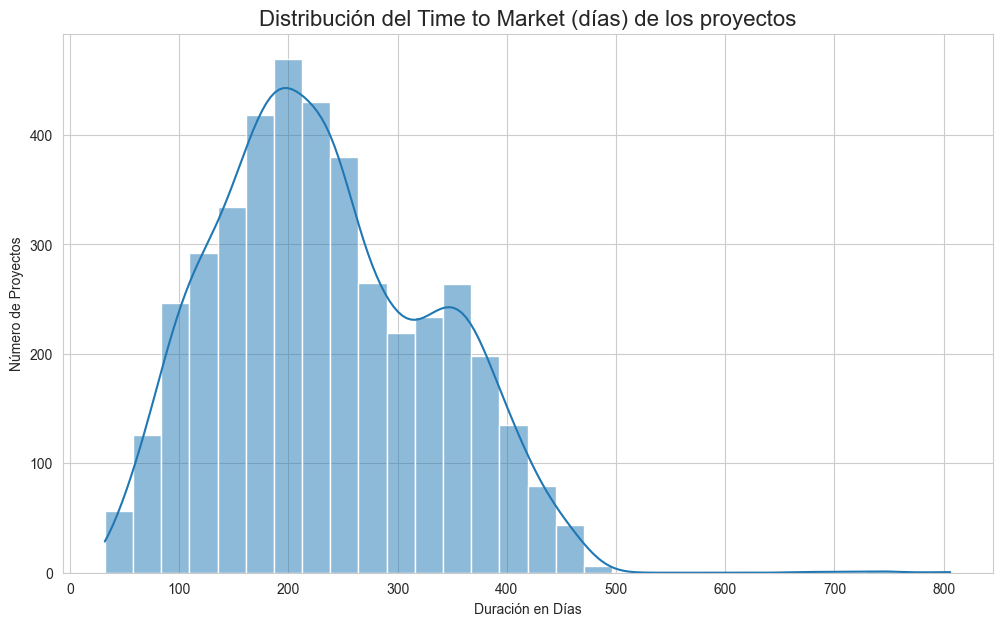

In [15]:
# --- Gráfico 1: Distribución del Time to Market ---
print("Generando Gráfico 1: Histograma del Time to Market...")
plt.figure(figsize=(12, 7))
sns.histplot(df['Time to market'].dropna(), kde=True, bins=30)
plt.title('Distribución del Time to Market (días) de los proyectos', fontsize=16)
plt.xlabel('Duración en Días')
plt.ylabel('Número de Proyectos')
plt.show()



Generando Gráfico 2: Distribución de Variables Categóricas...


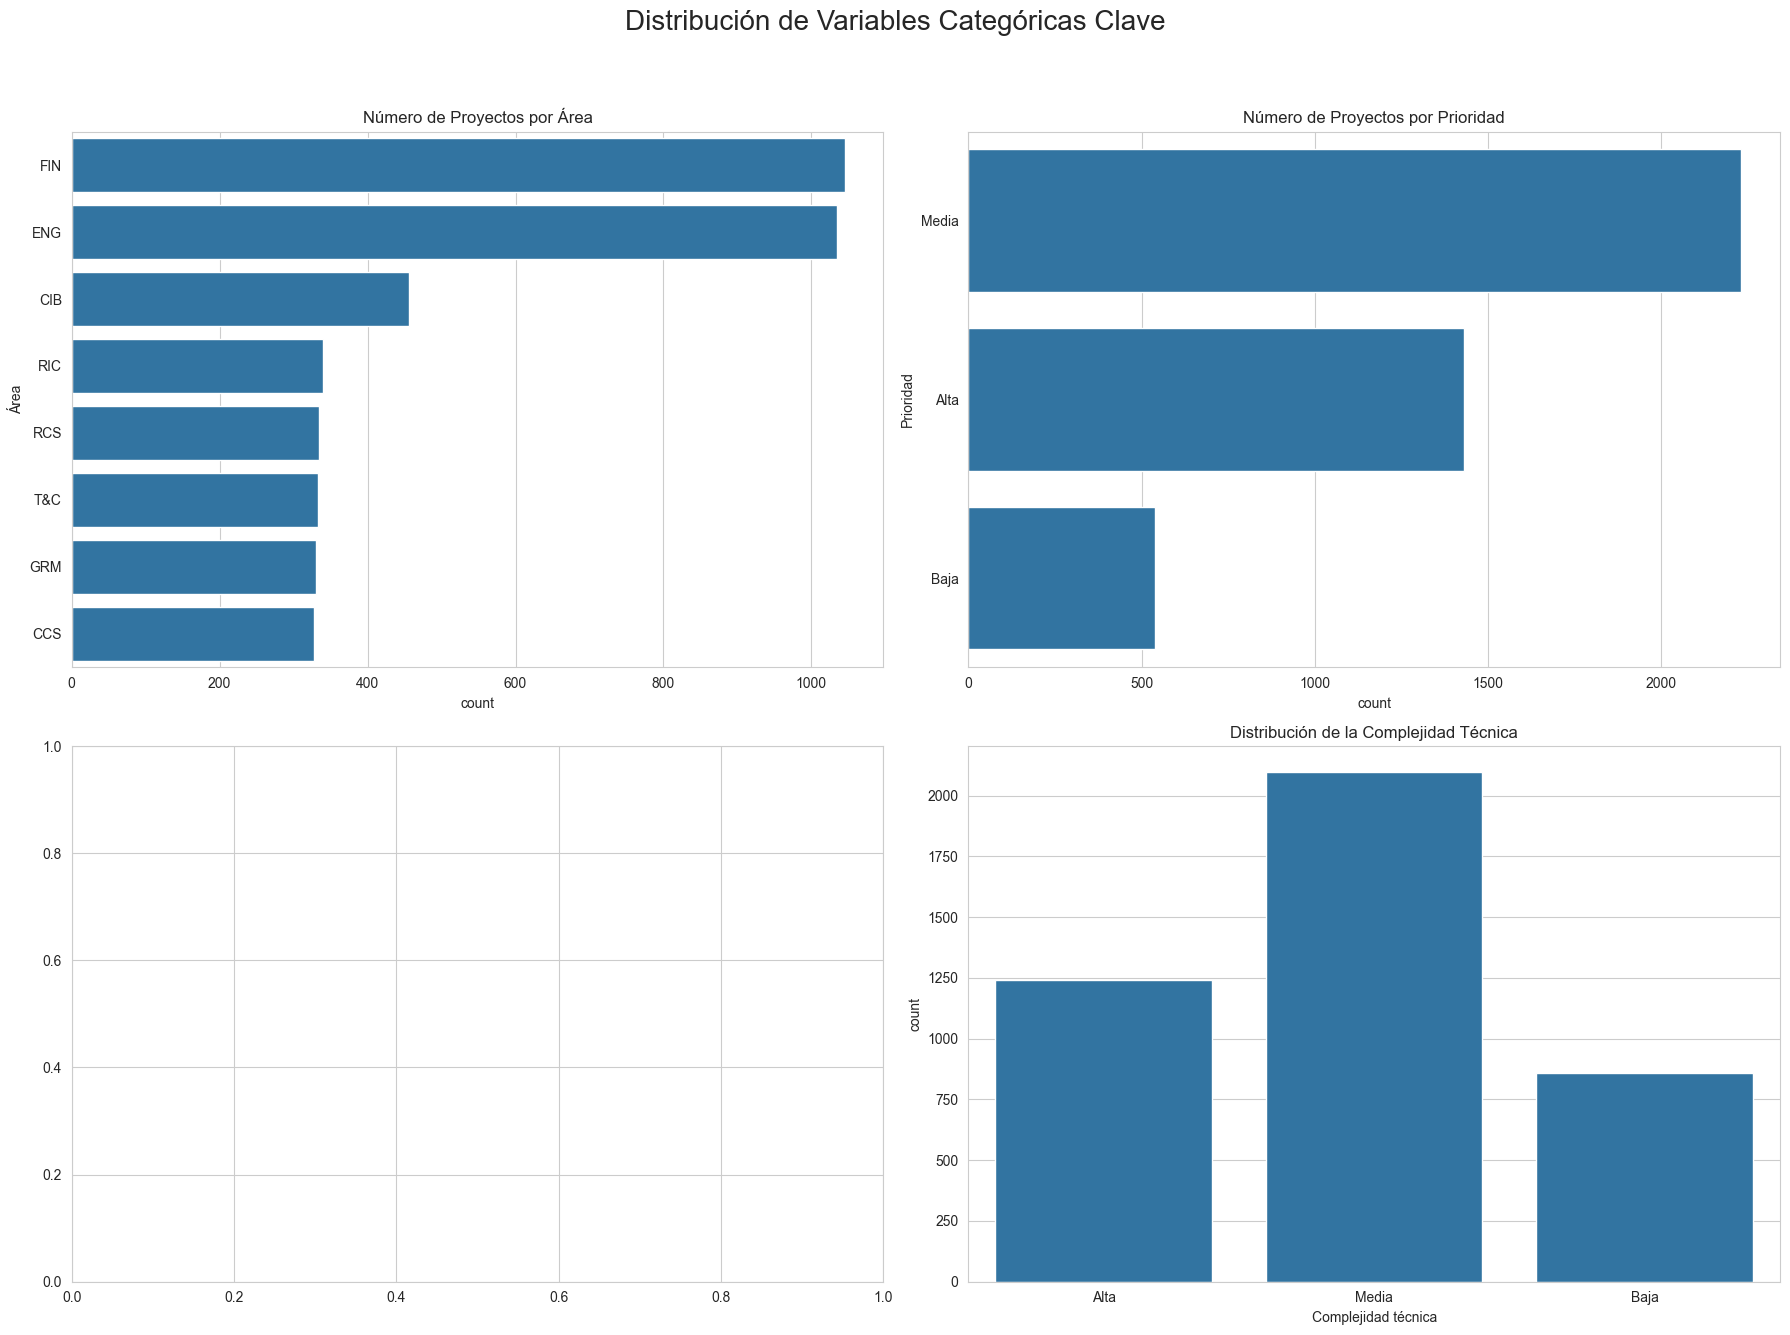

In [16]:
# --- Gráfico 2: Distribución de Variables Categóricas Clave ---
print("\nGenerando Gráfico 2: Distribución de Variables Categóricas...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Distribución de Variables Categóricas Clave', fontsize=20)

sns.countplot(ax=axes[0, 0], y=df['Área'], order=df['Área'].value_counts().index)
axes[0, 0].set_title('Número de Proyectos por Área')

sns.countplot(ax=axes[0, 1], y=df['Prioridad'], order=df['Prioridad'].value_counts().index)
axes[0, 1].set_title('Número de Proyectos por Prioridad')

sns.countplot(ax=axes[1, 1], x=df['Complejidad técnica'])
axes[1, 1].set_title('Distribución de la Complejidad Técnica')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generando gráfico: Número de Proyectos por Número de Dependencias Asociadas...


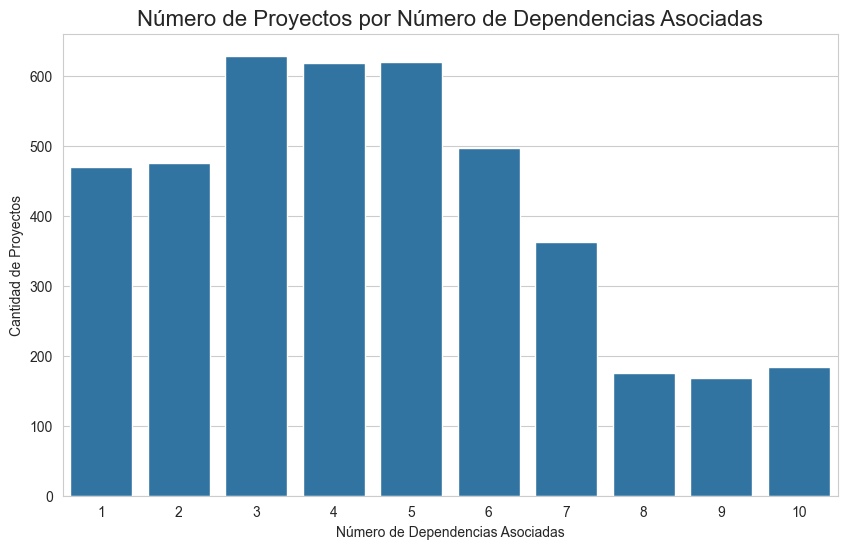

In [17]:
# --- Gráfico: Número de Proyectos por Número de Dependencias Pendientes ---
print("Generando gráfico: Número de Proyectos por Número de Dependencias Asociadas...")
plt.figure(figsize=(10, 6))
sns.countplot(x='Número de dependencias asociadas', data=df, order=sorted(df['Número de dependencias asociadas'].unique()))
plt.title('Número de Proyectos por Número de Dependencias Asociadas', fontsize=16)
plt.xlabel('Número de Dependencias Asociadas')
plt.ylabel('Cantidad de Proyectos')
plt.show()

Generando Gráfico 3: Boxplot de Time to Market por Área...


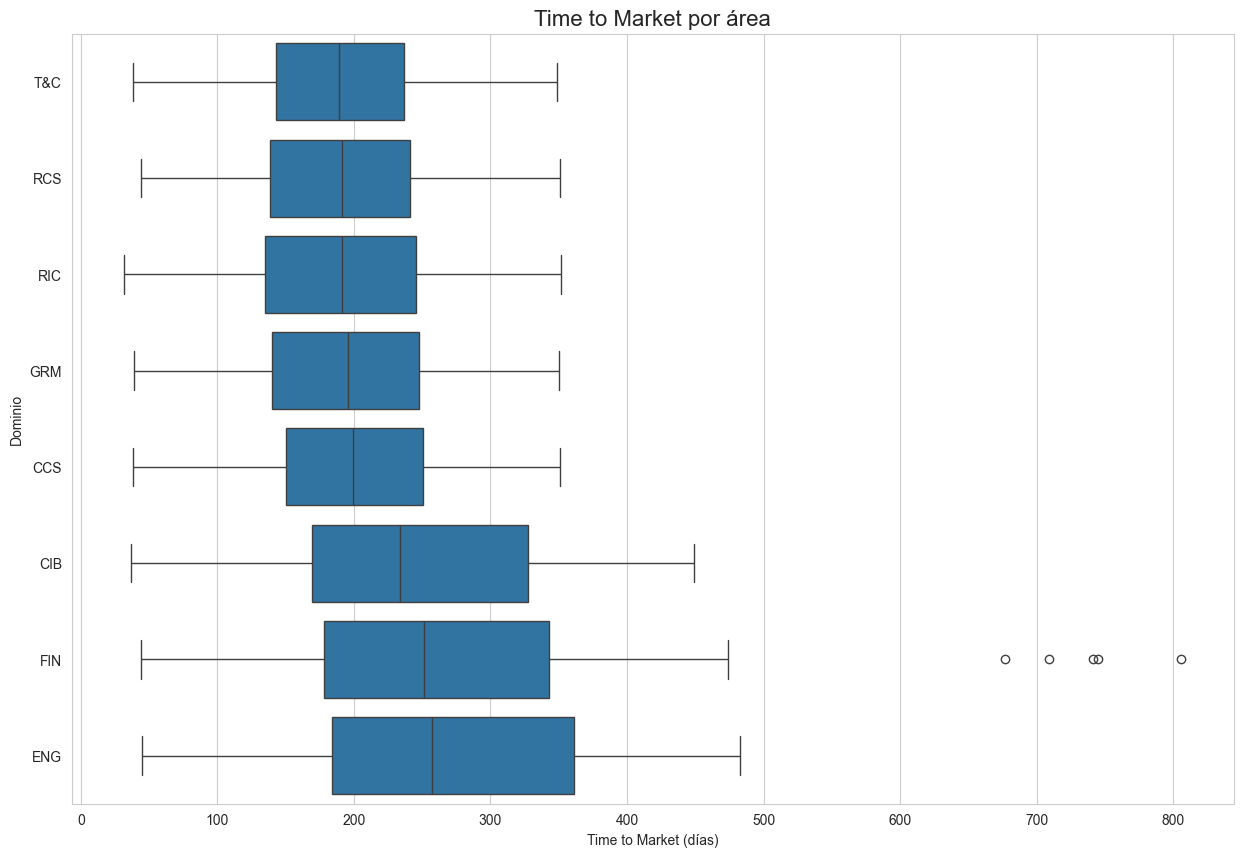

In [18]:
# --- Gráfico 3: Time to Market por Área ---
print("Generando Gráfico 3: Boxplot de Time to Market por Área...")
plt.figure(figsize=(15, 10))
# Ordenamos los áreas por su mediana de TTM para una mejor visualización
sorted_order = df.groupby('Área')['Time to market'].median().sort_values().index
sns.boxplot(y='Área', x='Time to market', data=df, order=sorted_order)
plt.title('Time to Market por área', fontsize=16)
plt.xlabel('Time to Market (días)')
plt.ylabel('Dominio')
plt.show()


Generando Gráfico 5: Boxplot de Time to Market por Complejidad Técnica...


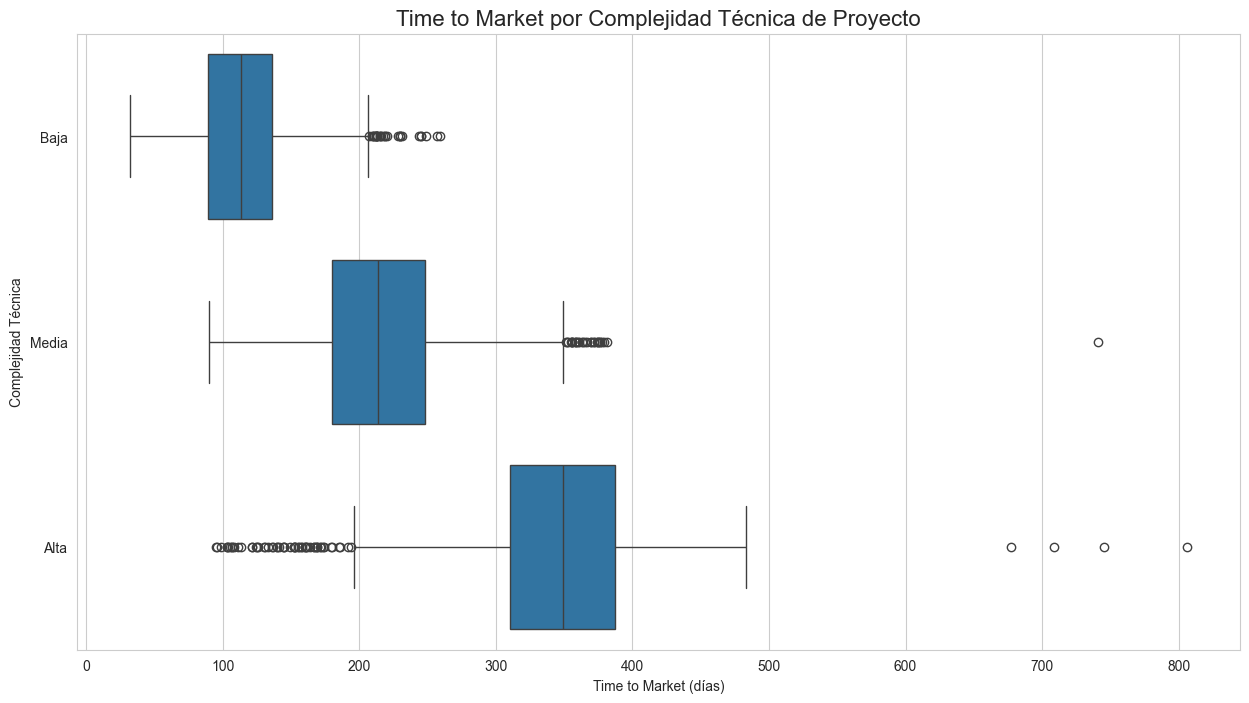

In [19]:
# --- Gráfico 5: Time to Market por Complejidad ---
print("\nGenerando Gráfico 5: Boxplot de Time to Market por Complejidad Técnica...")
plt.figure(figsize=(15, 8))
sorted_order_complejidad = df.groupby('Complejidad técnica')['Time to market'].median().sort_values().index
sns.boxplot(y='Complejidad técnica', x='Time to market', data=df, order=sorted_order_complejidad)
plt.title('Time to Market por Complejidad Técnica de Proyecto', fontsize=16)
plt.xlabel('Time to Market (días)')
plt.ylabel('Complejidad Técnica')
plt.show()


Generando Gráfico 4: Boxplot de Time to Market por Prioridad...


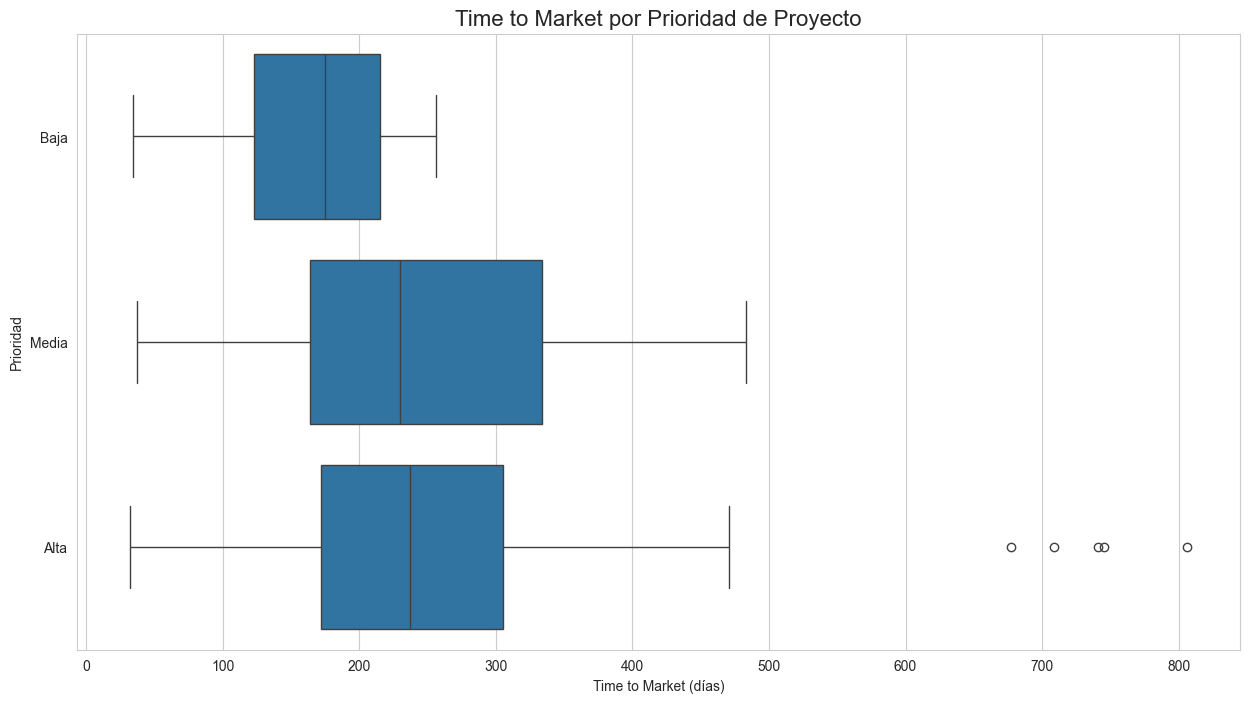

In [20]:
# --- Gráfico 4: Time to Market por Prioridad ---
print("\nGenerando Gráfico 4: Boxplot de Time to Market por Prioridad...")
plt.figure(figsize=(15, 8))
sorted_order_prioridad = df.groupby('Prioridad')['Time to market'].median().sort_values().index
sns.boxplot(y='Prioridad', x='Time to market', data=df, order=sorted_order_prioridad)
plt.title('Time to Market por Prioridad de Proyecto', fontsize=16)
plt.xlabel('Time to Market (días)')
plt.ylabel('Prioridad')
plt.show()


Generando Gráfico 5: Matriz de Correlación...


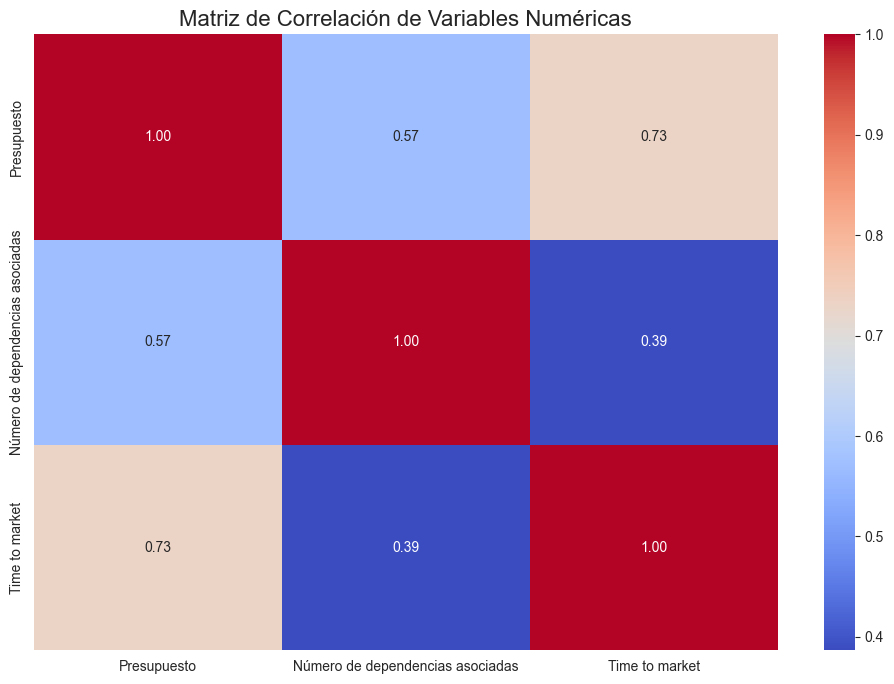

In [21]:

# --- Gráfico 5: Matriz de Correlación ---
print("\nGenerando Gráfico 5: Matriz de Correlación...")
plt.figure(figsize=(12, 8))
# Seleccionamos solo las columnas numéricas para el cálculo
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

In [22]:

print("\n--- Separando X (Predictoras) e y (Objetivo) ---")

predictor_cols = [
    'Área',
    'Complejidad técnica',
    'Prioridad',
    'Presupuesto',
    'Número de dependencias asociadas',
    'Fecha de inicio de ejecución',
]

X=df[predictor_cols].copy()

# PRERREQUISITO: Asegurar que la columna es un objeto datetime
# Usamos 'errors=coerce' por si alguna fecha estuviera mal formateada
X['Fecha de inicio de ejecución'] = pd.to_datetime(
    X['Fecha de inicio de ejecución'], 
    format='%d/%m/%Y',
    errors='coerce'
)

# CREACIÓN DE NUEVAS CARACTERÍSTICAS
X['Mes_Inicio'] = X['Fecha de inicio de ejecución'].dt.month
X['Trimestre_Inicio'] = X['Fecha de inicio de ejecución'].dt.quarter


print("Nuevas columnas 'Mes_Inicio' y 'Trimestre_Inicio' creadas.")

# --- 3. Resultado ---
# Mostramos las nuevas columnas junto a la original para verificar
print("\nResultado de la transformación:")
print(X[['Fecha de inicio de ejecución', 'Mes_Inicio', 'Trimestre_Inicio']].head())


--- Separando X (Predictoras) e y (Objetivo) ---
Nuevas columnas 'Mes_Inicio' y 'Trimestre_Inicio' creadas.

Resultado de la transformación:
  Fecha de inicio de ejecución  Mes_Inicio  Trimestre_Inicio
0                   2024-04-26           4                 2
1                   2022-10-21          10                 4
2                   2021-07-18           7                 3
3                   2021-10-09          10                 4
4                   2025-05-18           5                 2


In [23]:
print("\n--- 4. Codificando Variables Categóricas ---")

X = X.drop('Fecha de inicio de ejecución', axis=1)
# Identificamos las columnas que son texto (categóricas)
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()


print(f"Columnas a codificar (One-Hot): {categorical_cols}")

# Aplicamos One-Hot Encoding a las demás categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"El dataset X ahora tiene {X.shape[1]} columnas (features).")


--- 4. Codificando Variables Categóricas ---
Columnas a codificar (One-Hot): ['Área', 'Complejidad técnica', 'Prioridad']
El dataset X ahora tiene 15 columnas (features).


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df['Time to market']

print("\n--- 5. Dividiendo en datos de Entrenamiento y Prueba ---")
# Dividimos los datos: 80% para entrenar, 20% para probar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} proyectos.")
print(f"Datos de prueba: {X_test.shape[0]} proyectos.")


--- 5. Dividiendo en datos de Entrenamiento y Prueba ---
Datos de entrenamiento: 3360 proyectos.
Datos de prueba: 840 proyectos.


In [25]:
print("\n--- 6. Transformando y Escalando los datos ---")
import numpy as np

# 6a. Transformación Logarítmica de 'y' (Objetivo)
# Aplicamos logaritmo para normalizar la distribución del TTM (manejo de outliers)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print("Variable objetivo 'y' transformada con logaritmo.")


# 6b. Escalamiento de 'X' (Predictoras)
# Escalamos las variables numéricas para que tengan el mismo "peso"
numeric_features = ['Presupuesto', 'Número de dependencias asociadas', 'Mes_Inicio', 'Trimestre_Inicio']
cols_to_scale = [col for col in numeric_features if col in X_train.columns] # Artefacto 3

scaler = StandardScaler()
# AJUSTAMOS el scaler SOLO con datos de ENTRENAMIENTO 
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# TRANSFORMAMOS los datos de PRUEBA con el scaler ya ajustado
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
print("Variables numéricas de X escaladas (StandardScaler).")


--- 6. Transformando y Escalando los datos ---
Variable objetivo 'y' transformada con logaritmo.
Variables numéricas de X escaladas (StandardScaler).


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Inicializar los modelos
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

# 2. Entrenar (fit) cada modelo
for name, model in models.items():
    print(f"Entrenando modelo: {name}...")
    model.fit(X_train, y_train_log)

print("Los modelos están listos en la variable 'models'.")
print("Las variables de prueba son: X_test, y_test_log, y_test")

Entrenando modelo: Linear Regression...
Entrenando modelo: Ridge Regression...
Entrenando modelo: Random Forest...
Los modelos están listos en la variable 'models'.
Las variables de prueba son: X_test, y_test_log, y_test


In [32]:
print("\n--- Iniciando Fase 5: Evaluación ---")
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results_list = []

for name, model in models.items():
    print(f"\n--- Evaluando: {name} ---")
    
    # 1. Hacer predicciones (en escala logarítmica)
    y_pred_log = model.predict(X_test)
    
    # 2. Revertir la transformación (convertir de log a días)
    # Usamos np.expm1 (inverso de log1p)
    y_pred_dias = np.expm1(y_pred_log)
    
    # 3. Calcular métricas comparando con 'y_test' (los días reales)
    r2 = r2_score(y_test, y_pred_dias)
    mae = mean_absolute_error(y_test, y_pred_dias)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_dias))
    
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): {mae:.2f} días")
    print(f"Raíz Error Cuadrático Medio (RMSE): {rmse:.2f} días")
    
    # Guardar resultados para el resumen
    results_list.append([name, r2, mae, rmse])

# --- Resumen Final ---
print("\n--- Resumen de Evaluación de Modelos ---")
results_df = pd.DataFrame(results_list, columns=['Modelo', 'R-cuadrado (R²)', 'MAE (días)', 'RMSE (días)'])
print(results_df.to_markdown(index=False, floatfmt=".4f"))
model_ganador = models['Random Forest']



--- Iniciando Fase 5: Evaluación ---

--- Evaluando: Linear Regression ---
R-cuadrado (R²): 0.7210
Error Absoluto Medio (MAE): 38.85 días
Raíz Error Cuadrático Medio (RMSE): 52.48 días

--- Evaluando: Ridge Regression ---
R-cuadrado (R²): 0.7199
Error Absoluto Medio (MAE): 38.94 días
Raíz Error Cuadrático Medio (RMSE): 52.58 días

--- Evaluando: Random Forest ---
R-cuadrado (R²): 0.7616
Error Absoluto Medio (MAE): 34.71 días
Raíz Error Cuadrático Medio (RMSE): 48.52 días

--- Resumen de Evaluación de Modelos ---
| Modelo            |   R-cuadrado (R²) |   MAE (días) |   RMSE (días) |
|:------------------|------------------:|-------------:|--------------:|
| Linear Regression |            0.7210 |      38.8525 |       52.4812 |
| Ridge Regression  |            0.7199 |      38.9413 |       52.5839 |
| Random Forest     |            0.7616 |      34.7083 |       48.5156 |


In [ ]:
import os


print("\n\n--- [PARTE 2] Iniciando Fase 6: Despliegue por Lotes ---")

# --- Definir Nombres de Archivos y Carpetas ---
input_filename = 'proyectos_data.xlsx'
output_folder = 'resultados'
output_filename = 'proyectos_evaluados.xlsx'
output_path = os.path.join(output_folder, output_filename)

# Crear la carpeta 'resultados' si no existe
os.makedirs(output_folder, exist_ok=True)

# --- Definir la Función de Predicción por Lotes ---

def generar_predicciones_lote(archivo_entrada, archivo_salida_path, 
                             model, scaler, model_cols, cat_cols, num_cols):
    """
    Carga un Excel, aplica todas las transformaciones y predice el TTM.
    Guarda un nuevo Excel en la ruta de salida.
    """
    
    print(f"\n2. Cargando '{archivo_entrada}'...")
    try:
        df_new = pd.read_excel(archivo_entrada)
    except ImportError:
        print("ERROR: Necesitas 'openpyxl'. Ejecuta: pip install openpyxl")
        return None
    except FileNotFoundError:
        print(f"ERROR: No se encontró el archivo '{archivo_entrada}'")
        return None
        
    df_output = df_new.copy()
    
    # Extraer solo las columnas que el modelo necesita
    predictor_cols_base = ['Área', 'Complejidad técnica', 'Prioridad', 'Presupuesto', 
                           'Número de dependencias asociadas', 'Fecha de inicio de ejecución']
    X_new = df_new[predictor_cols_base].copy()

    print("3. Aplicando transformaciones (Fase 3)...")
    
    # Presupuesto: Convertir de texto a float
    X_new['Presupuesto'] = X_new['Presupuesto'].apply(parse_amount)
    
    # Formatos de fecha: Convertir a datetime
    X_new['Fecha de inicio de ejecución'] = pd.to_datetime(X_new['Fecha de inicio de ejecución'], format='%d/%m/%Y', errors='coerce')
    df_output['Fecha de inicio de ejecución'] = pd.to_datetime(df_output['Fecha de inicio de ejecución'], format='%d/%m/%Y', errors='coerce')
    df_output['Fecha de uso por cliente planificada'] = pd.to_datetime(df_output['Fecha de uso por cliente planificada'], format='%d/%m/%Y', errors='coerce')
    
    # Calcular TTM Planificado (días)
    df_output['TTM_Planificado_dias'] = (df_output['Fecha de uso por cliente planificada'] - df_output['Fecha de inicio de ejecución']).dt.days
    
    # Feature Engineering: Mes y Trimestre de Inicio
    X_new['Mes_Inicio'] = X_new['Fecha de inicio de ejecución'].dt.month
    X_new['Trimestre_Inicio'] = X_new['Fecha de inicio de ejecución'].dt.quarter
    X_new = X_new.drop('Fecha de inicio de ejecución', axis=1)
    
    # Codificar variables categóricas (One-Hot Encoding)
    X_new = pd.get_dummies(X_new, columns=cat_cols, drop_first=True)
    
    # Reindexar (CRUCIAL: alinear columnas con las del entrenamiento)
    X_new = X_new.reindex(columns=model_cols, fill_value=0)
    
    # Escalar las variables numéricas
    X_new[num_cols] = scaler.transform(X_new[num_cols])
    
    print("4. Realizando predicciones con el modelo Random Forest...")
    
    # 4. Hacer la predicción
    pred_log = model.predict(X_new)
    
    # [cite_start]5. Revertir la transformación (log -> días) [cite: 644]
    pred_dias = np.expm1(pred_log)
    
    print("5. Calculando retraso y alertas...")
    
    # 6. Añadir resultados al DataFrame de salida
    df_output['TTM_Proyectado_dias'] = pred_dias
    df_output['Retraso_Estimado_dias'] = df_output['TTM_Proyectado_dias'] - df_output['TTM_Planificado_dias']
    df_output['Alerta'] = np.where(df_output['Retraso_Estimado_dias'] > 0, 'Alerta: Posible Retraso', 'En Tiempo')


    df_output['TTM_Proyectado_dias'] = df_output['TTM_Proyectado_dias'].round(2)
    df_output['Retraso_Estimado_dias'] = df_output['Retraso_Estimado_dias'].round(2)
    
    date_cols_output = ['Fecha de inicio de ejecución', 'Fecha de uso por cliente planificada']
    for col in date_cols_output:
        if col in df_output.columns:
            # .dt.strftime solo funciona en columnas datetime
            df_output[col] = df_output[col].dt.strftime('%d/%m/%Y')
    
    # 7. Guardar el nuevo Excel en la carpeta especificada
    df_output.to_excel(archivo_salida_path, index=False)
    print(f"6. ¡Éxito! Resultados guardados en '{archivo_salida_path}'")
    
    return df_output

# --- Ejecutar el Proceso de Despliegue ---
model_columns = X.columns.tolist() # Artefacto 2

# Usamos los "artefactos" creados en la Parte 1
resultados = generar_predicciones_lote(
    archivo_entrada = input_filename,
    archivo_salida_path = output_path,
    model = model_ganador,
    scaler = scaler,
    model_cols = model_columns,
    cat_cols = categorical_cols,
    num_cols = cols_to_scale
)

if resultados is not None:
    print("\n--- 🚀 Resumen de Predicciones ---")
    # Imprimir el resumen en formato markdown para una visualización limpia
    print(resultados[['SDATOOL', 'TTM_Planificado_dias', 'TTM_Proyectado_dias', 'Retraso_Estimado_dias', 'Alerta']].to_markdown(index=False, floatfmt=".0f"))



--- [PARTE 2] Iniciando Fase 6: Despliegue por Lotes ---

2. Cargando 'proyectos_data.xlsx'...
3. Aplicando transformaciones (Fase 3)...
4. Realizando predicciones con el modelo Random Forest...
5. Calculando retraso y alertas...
6. ¡Éxito! Resultados guardados en 'resultados\proyectos_evaluados.xlsx'

--- 🚀 Resumen de Predicciones ---
| SDATOOL      |   TTM_Planificado_dias |   TTM_Proyectado_dias |   Retraso_Estimado_dias | Alerta                  |
|:-------------|-----------------------:|----------------------:|------------------------:|:------------------------|
| SDATOOL-1021 |                    241 |                   381 |                     140 | Alerta: Posible Retraso |
| SDATOOL-1022 |                    191 |                    98 |                     -93 | En Tiempo               |
| SDATOOL-1023 |                    234 |                   205 |                     -29 | En Tiempo               |
| SDATOOL-1024 |                    334 |                   380 |     